In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

## After training (V1)

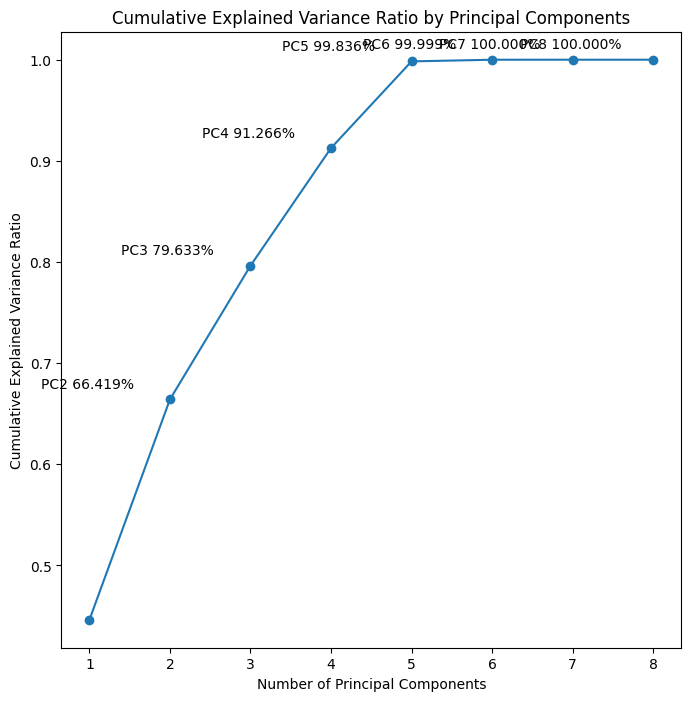

In [40]:
import os
from utils.explained_variance_ratio import explained_variance
from script.shell import MinimalTransformer # this dimension and all the params should match the file saved in .pth
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)

checkpoint_dir = os.path.join(PROJECT_ROOT, 'checkpoints')
file_name = 'v1.pth'
full_path = os.path.join(checkpoint_dir, file_name)


explained_variance(full_path, model=model, pc=8)

## V(2)


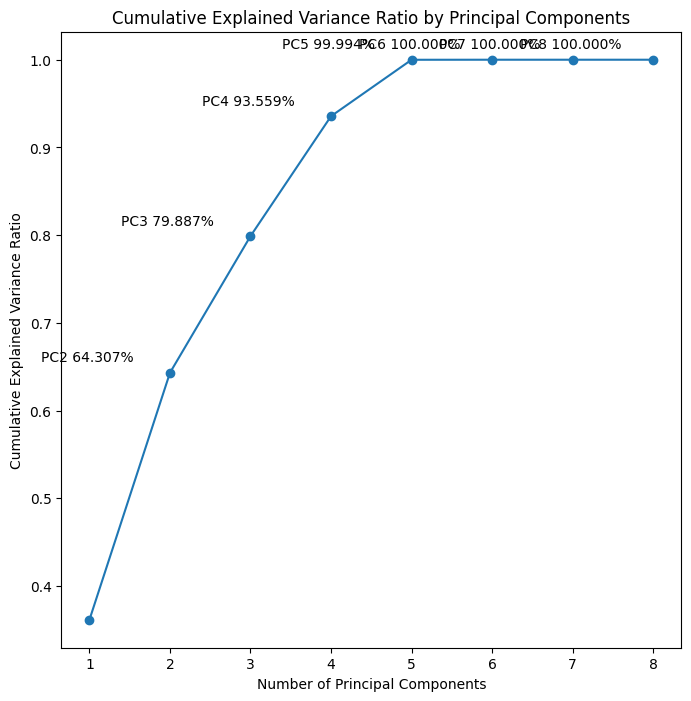

In [41]:
from script.shell import MinimalTransformer
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)
explained_variance(os.path.join(checkpoint_dir, 'v2.pth'), model, pc=8)

V(3)

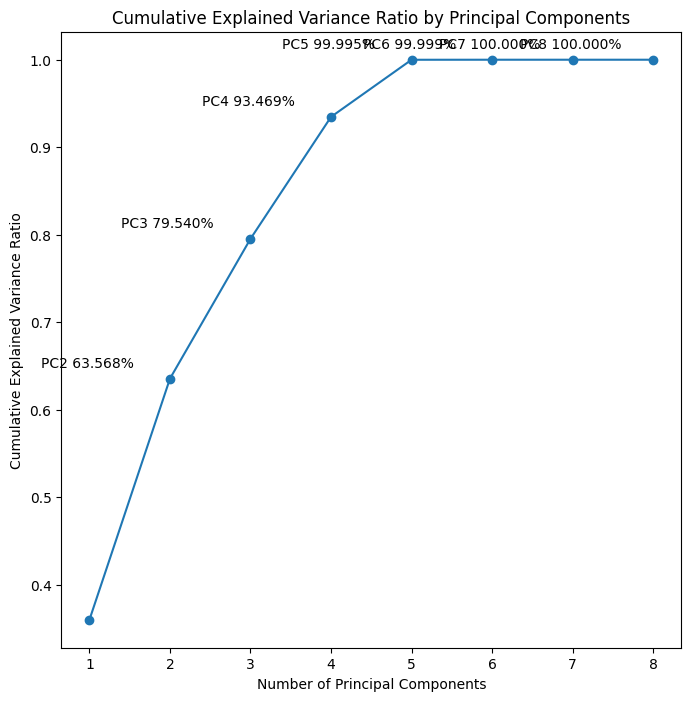

In [42]:
from script.shell import MinimalTransformer 
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)

explained_variance(os.path.join(checkpoint_dir, 'v3.pth'), model, pc=8)

## Before training

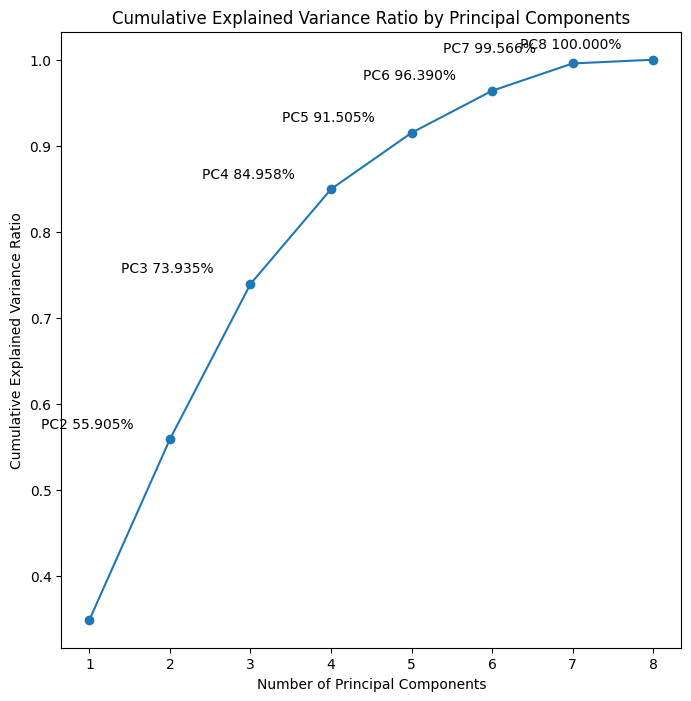

In [43]:
from script.shell import MinimalTransformer
file_name = 'v1_initial.pth'
full_path = os.path.join(checkpoint_dir, file_name)
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)
explained_variance(full_path, model, pc=8)

## Dimensional reduction explained variance ratio

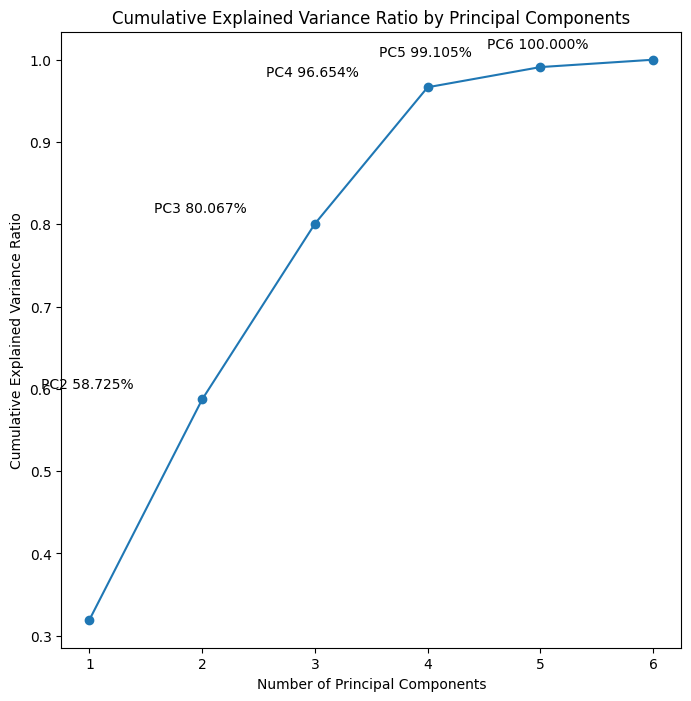

In [44]:
from script.model_dim_6 import MinimalTransformer 
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)
checkpoint_dir = '../checkpoints'
explained_variance(os.path.join(checkpoint_dir, 'dim_6_mlp.pth'), model, pc=6)

## Dimensional reduction, with accuracy plot

99.12421052631579


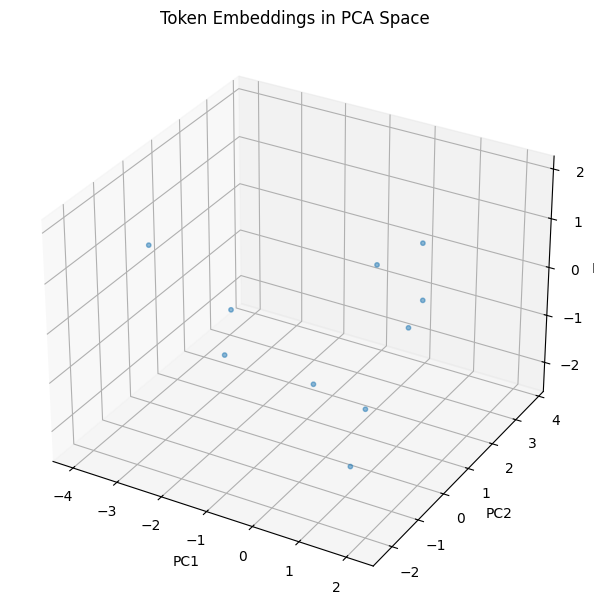

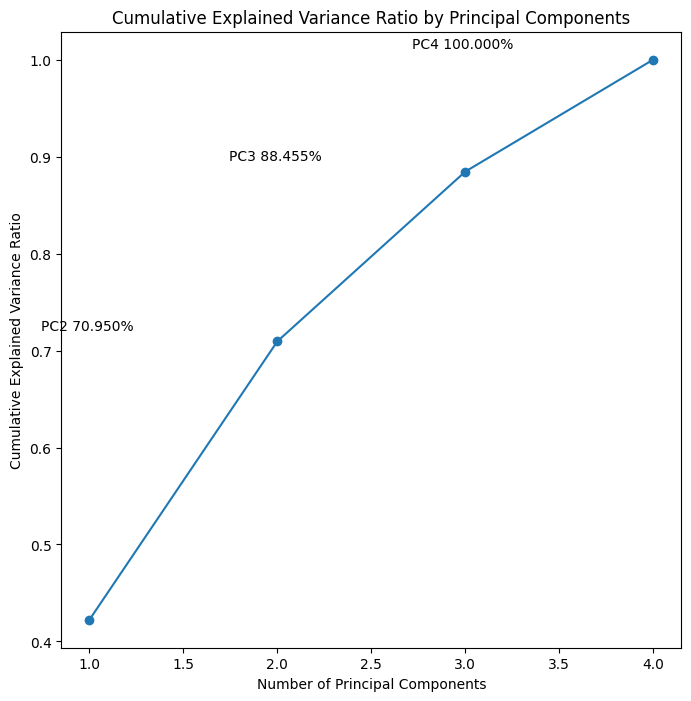

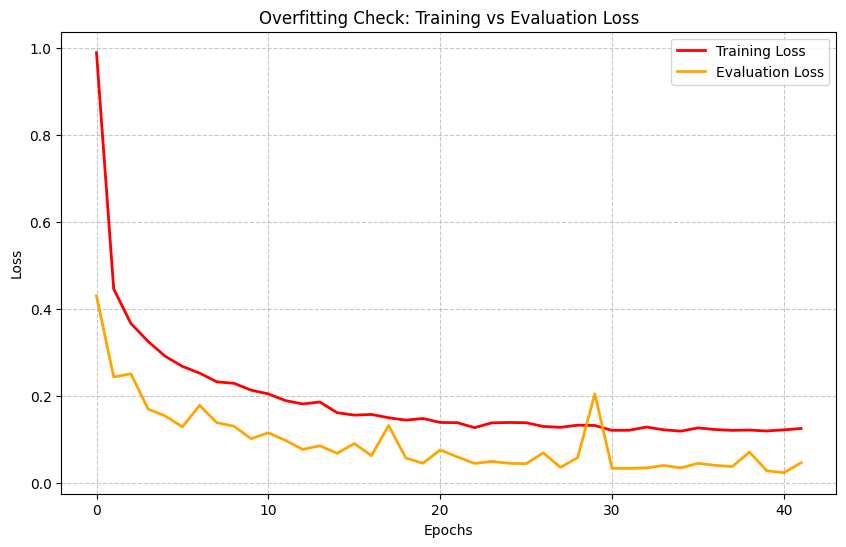

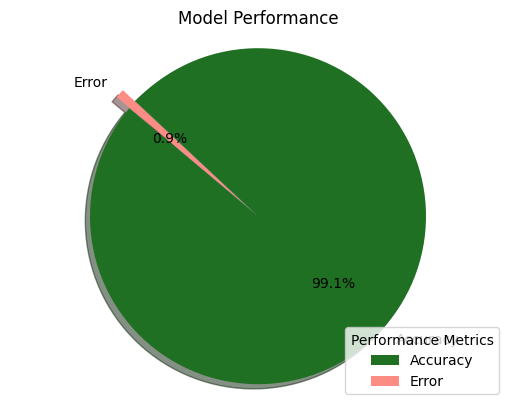

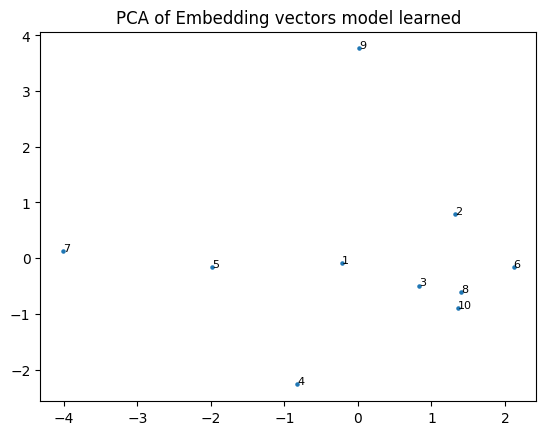

Dimension of model: 4


In [45]:
import torch
from utils.explained_variance_ratio import explained_variance, overfitting_plot, pca_analysis, plot_3d, accuracy_plot
from script.model_dim_4_layer_3 import MinimalTransformer 


vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)
checkpoint_dir = '../checkpoints'
full_path = os.path.join(checkpoint_dir, 'dim_4_layer_3.pth')

checkpoint = torch.load(full_path)

train_plot = checkpoint['train_loss_history']
eval_plot = checkpoint['eval_loss_history']

eval_accuracy = checkpoint.get("total_accuracy")
dimension = checkpoint.get("d_model")
print(eval_accuracy)

plot_3d(full_path, model, pc=3)
explained_variance(full_path, model, pc=4)
overfitting_plot(train_plot, eval_plot)
accuracy_plot(eval_accuracy)
pca_analysis(model=model, pc=4)

print(f"Dimension of model: {dimension}")
